In [30]:
import numpy as np

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
        self.betas        = beta_matrix
        self.comp_designs = competitor_designs
        self.market_size  = market_size

        # Pre-calculate competitor utilities since they remain constant
        # Shape: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    # Single-product evaluation 

    def evaluate_product(self, our_design, our_price, our_cost, price_betas):
        feature_utility = np.dot(self.betas, our_design.T)
        price_utilities = price_betas * our_price
        our_utility     = feature_utility + price_utilities

        all_utilities = np.hstack((self.comp_utilities, our_utility))
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)

        our_probabilities = probabilities[:, -1]
        market_share      = np.mean(our_probabilities)
        unit_sales        = market_share * self.market_size
        profit            = unit_sales * (our_price - our_cost)
        return market_share, profit

    # Portfolio evaluation 

    def evaluate_portfolio(self, our_designs, our_prices, our_costs, price_betas):
        """
        our_designs : (N, total_levels)   one row per product, already one-hot encoded
        our_prices  : (N,)                one price per product
        our_costs   : (N,)                one cost per product
        price_betas : (num_respondents, 1)

        Returns
        -------
        individual_shares : (N,)   market share of each product
        portfolio_share   : float  sum of individual shares
        portfolio_profit  : float  total profit across portfolio
        """
        # Feature utilities for all N products: (num_respondents, N)
        feature_utilities = np.dot(self.betas, our_designs.T)

        # Price utilities: price_betas (respondents, 1) * our_prices (N,)
        # NumPy broadcasting gives (respondents, N) automatically
        price_utilities = price_betas * our_prices

        our_utilities = feature_utilities + price_utilities  # (respondents, N)

        # Stack: [competitor columns | our product columns]
        # Shape: (respondents, num_competitors + N)
        all_utilities = np.hstack((self.comp_utilities, our_utilities))

        # MNL rule — identical formula to the single-product case
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)

        # Extract our N columns (everything after the competitor columns)
        num_comp  = self.comp_utilities.shape[1]
        our_probs = probabilities[:, num_comp:]  # (respondents, N)

        # Average across respondents -> one share per product
        individual_shares = np.mean(our_probs, axis=0)  # (N,)

        portfolio_share  = np.sum(individual_shares)
        unit_sales       = individual_shares * self.market_size
        portfolio_profit = np.sum(unit_sales * (our_prices - our_costs))

        return individual_shares, portfolio_share, portfolio_profit

In [31]:
import numpy as np

# Define product attributes - ("Attribute name", <no. of levels>)
attributes = [
    ("Attribute 1", 5),
    ("Attribute 2", 2),
    ("Attribute 3", 2),
    ("Attribute 5", 3)
]

# Define Competitors 
competitors = [
    {"name": "Competitor A", "price": 2.00, "levels": [4, 0, 0, 2]},
    {"name": "Competitor B", "price": 3.50, "levels": [2, 1, 1, 2]},
    {"name": "Competitor C", "price": 5.00, "levels": [2, 1, 0, 2]},
]

# --- Define YOUR candidate products ---
# The optimizer will pick the best NUM_PRODUCTS from this list and price them
our_products = [
    {"name": "Product 1", "levels": [4, 0, 0, 2]},
    {"name": "Product 2", "levels": [0, 0, 1, 2]},
    {"name": "Product 3", "levels": [0, 1, 0, 1]},
    {"name": "Product 4", "levels": [1, 0, 0, 0]},
    {"name": "Product 5", "levels": [1, 1, 1, 2]},
    {"name": "Product 6", "levels": [3, 0, 1, 0]},
    {"name": "Product 7", "levels": [2, 1, 0, 0]},
    {"name": "Product 8", "levels": [4, 1, 1, 1]},
]

# --- Number of products to include in the final portfolio ---
NUM_PRODUCTS = int(input("Enter the number of products to be used in the final portfolio: "))

# --- Automatically derive everything else — DO NOT TOUCH ---
num_levels    = [a[1] for a in attributes]
total_levels  = sum(num_levels)
start_indices = [sum(num_levels[:i]) for i in range(len(num_levels))]
# Validate that every product and competitor has the right number of levels
for prod in our_products:
    assert len(prod["levels"]) == len(attributes), \
        f"{prod['name']} has {len(prod['levels'])} level values but there are {len(attributes)} attributes"

for comp in competitors:
    assert len(comp["levels"]) == len(attributes), \
        f"{comp['name']} has {len(comp['levels'])} level values but there are {len(attributes)} attributes"

print("Validation passed — all products and competitors have the correct number of levels")

# Build competitor one-hot matrix
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1

comp_prices = np.array([[c["price"]] for c in competitors])

# Build candidate product one-hot matrix — one row per candidate
candidate_designs = np.zeros((len(our_products), total_levels), dtype=int)
for row, prod in enumerate(our_products):
    for attr_i, level_choice in enumerate(prod["levels"]):
        candidate_designs[row, start_indices[attr_i] + level_choice] = 1

print(f"Attributes     : {[a[0] for a in attributes]}")
print(f"Levels per attr: {num_levels}")
print(f"Competitors    : {len(competitors)}")
print(f"Candidates     : {len(our_products)}  ->  picking best {NUM_PRODUCTS}")
print(f"\nCandidate designs matrix:\n{candidate_designs}")

# --- Dummy survey data ---
np.random.seed(42)
num_respondents = 100
dummy_betas     = np.random.normal(loc=0.0, scale=1.5,
                                   size=(num_respondents, total_levels))
price_betas     = np.random.normal(loc=-0.8, scale=0.2,
                                   size=(num_respondents, 1))

market_size           = int(input("Enter the total market size (e.g., 500000): "))
our_cost              = float(input("Enter product unit cost in dollars (e.g., 0.85): "))
price_min, price_max  = map(float, input("Enter the price search range (e.g., 1.00-5.00): ").split("-"))

if price_min <= our_cost:
    price_min = our_cost
    print(f"Warning: Minimum price was below cost. Adjusted to ${price_min:.2f}")

# --- Instantiate simulator ---
simulator = MarketSimulator(dummy_betas, competitor_matrix, market_size)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

Enter the number of products to be used in the final portfolio:  6


Validation passed — all products and competitors have the correct number of levels
Attributes     : ['Attribute 1', 'Attribute 2', 'Attribute 3', 'Attribute 5']
Levels per attr: [5, 2, 2, 3]
Competitors    : 3
Candidates     : 8  ->  picking best 6

Candidate designs matrix:
[[0 0 0 0 1 1 0 1 0 0 0 1]
 [1 0 0 0 0 1 0 0 1 0 0 1]
 [1 0 0 0 0 0 1 1 0 0 1 0]
 [0 1 0 0 0 1 0 1 0 1 0 0]
 [0 1 0 0 0 0 1 0 1 0 0 1]
 [0 0 0 1 0 1 0 0 1 1 0 0]
 [0 0 1 0 0 0 1 1 0 1 0 0]
 [0 0 0 0 1 0 1 0 1 0 1 0]]


Enter the total market size (e.g., 500000):  50000
Enter product unit cost in dollars (e.g., 0.85):  0.5
Enter the price search range (e.g., 1.00-5.00):  0.2-3


In [32]:
# Pick 3 candidates by index and assign test prices to verify the simulator.

test_indices = list(range(NUM_PRODUCTS))    
test_prices  = [2.0 + i * 0.5 for i in range(NUM_PRODUCTS)]

test_designs = candidate_designs[test_indices]     # just index into the pre-built matrix
test_costs   = np.full(NUM_PRODUCTS, our_cost)

indiv_shares, port_share, port_profit = simulator.evaluate_portfolio(
    test_designs, np.array(test_prices), test_costs, price_betas
)

# Run the first product alone to show the cannibalization effect
p1_share_alone, _ = simulator.evaluate_product(
    test_designs[0:1], test_prices[0], our_cost, price_betas
)

print("--- Portfolio sanity check ---")
for i, (idx, s, p) in enumerate(zip(test_indices, indiv_shares, test_prices)):
    print(f"  Slot P{i+1}: {our_products[idx]['name']:<12} | share = {s*100:.2f}%  |  price = ${p:.2f}")
print(f"\n  Portfolio share  : {port_share*100:.2f}%")
print(f"  Portfolio profit : ${port_profit:,.2f}")
print(f"\n  {our_products[test_indices[0]]['name']} alone : {p1_share_alone*100:.2f}%")
print(f"  {our_products[test_indices[0]]['name']} in portfolio : {indiv_shares[0]*100:.2f}%")
print(f"  Cannibalization  : -{(p1_share_alone - indiv_shares[0])*100:.2f} pp")

--- Portfolio sanity check ---
  Slot P1: Product 1    | share = 14.87%  |  price = $2.00
  Slot P2: Product 2    | share = 17.31%  |  price = $2.50
  Slot P3: Product 3    | share = 15.04%  |  price = $3.00
  Slot P4: Product 4    | share = 10.00%  |  price = $3.50
  Slot P5: Product 5    | share = 6.65%  |  price = $4.00
  Slot P6: Product 6    | share = 7.32%  |  price = $4.50

  Portfolio share  : 71.19%
  Portfolio profit : $88,536.16

  Product 1 alone : 31.47%
  Product 1 in portfolio : 14.87%
  Cannibalization  : -16.60 pp


In [33]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

class PortfolioOptimizer(ElementwiseProblem):

    def __init__(self, sim, price_betas, candidate_designs, our_products,
                 num_products, our_cost, price_min, price_max):
        self.sim               = sim
        self.price_betas       = price_betas
        self.candidate_designs = candidate_designs
        self.num_products      = num_products
        self.our_cost          = our_cost
        self.num_candidates    = len(our_products)

        lower_one = np.array([0,                        price_min])
        upper_one = np.array([self.num_candidates - 1,  price_max])
        xl = np.tile(lower_one, num_products)
        xu = np.tile(upper_one, num_products)

        super().__init__(n_var=num_products * 2, n_obj=2, xl=xl, xu=xu)

    def _evaluate(self, x, out, *args, **kwargs):
        designs_list = []
        prices_list  = []

        for i in range(self.num_products):
            offset        = i * 2
            candidate_idx = int(round(x[offset]))
            price         = x[offset + 1]
            designs_list.append(self.candidate_designs[candidate_idx])
            prices_list.append(price)

        designs_matrix = np.array(designs_list)
        prices_array   = np.array(prices_list)
        costs_array    = np.full(self.num_products, self.our_cost)

        _, portfolio_share, portfolio_profit = self.sim.evaluate_portfolio(
            designs_matrix, prices_array, costs_array, self.price_betas
        )

        out["F"] = [-portfolio_share, -portfolio_profit]

In [34]:
res = minimize(
    PortfolioOptimizer(simulator, price_betas, candidate_designs, our_products,
                       NUM_PRODUCTS, our_cost, price_min, price_max),
    NSGA2(pop_size=200),
    ('n_gen', 200),
    verbose=False
)

portfolio_shares  = -res.F[:, 0] * 100
portfolio_profits = -res.F[:, 1]

# --- Decode helper ---
def decode_solution(x_sol):
    products = []
    for i in range(NUM_PRODUCTS):
        offset = i * 2
        idx   = int(round(x_sol[offset]))
        price = x_sol[offset + 1]
        products.append({"name": our_products[idx]["name"],
                         "levels": our_products[idx]["levels"],
                         "price": price})
    return products

def print_solution(label, x_sol, share, profit):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  Portfolio share: {share:.2f}%  |  Profit: ${profit:,.2f}")
    print(f"  {'─'*55}")
    print(f"  {'Slot':<6} {'Product':<14} {'Levels':<20} {'Price':>8}")
    for i, p in enumerate(decode_solution(x_sol)):
        print(f"  P{i+1:<5} {p['name']:<14} {str(p['levels']):<20} ${p['price']:>6.2f}")

# --- Pareto summary ---
print(f"Found {len(res.F)} Pareto-optimal portfolios\n" + "-"*45)
print(f"{'Portfolio Share':>18}  {'Portfolio Profit':>18}")
print("-"*40)
for share, profit in zip(portfolio_shares, portfolio_profits):
    print(f"{share:>17.2f}%  ${profit:>17,.2f}")

# --- Print the two extremes ---
best_share_idx  = np.argmax(portfolio_shares)
best_profit_idx = np.argmax(portfolio_profits)

print_solution("MAX PORTFOLIO SHARE",
               res.X[best_share_idx],
               portfolio_shares[best_share_idx],
               portfolio_profits[best_share_idx])

print_solution("MAX PORTFOLIO PROFIT",
               res.X[best_profit_idx],
               portfolio_shares[best_profit_idx],
               portfolio_profits[best_profit_idx])

Found 200 Pareto-optimal portfolios
---------------------------------------------
   Portfolio Share    Portfolio Profit
----------------------------------------
            72.34%  $        88,163.06
            72.34%  $        88,163.06
            92.08%  $           921.29
            74.85%  $        85,592.40
            84.97%  $        54,907.88
            87.55%  $        40,255.66
            75.15%  $        85,138.17
            86.73%  $        45,868.18
            91.24%  $        11,174.64
            74.37%  $        86,000.88
            87.74%  $        39,135.71
            90.45%  $        19,015.75
            89.58%  $        26,231.57
            78.33%  $        78,336.02
            83.45%  $        61,670.79
            80.74%  $        71,516.93
            84.79%  $        55,697.43
            79.92%  $        73,951.44
            88.08%  $        36,894.15
            77.53%  $        80,355.73
            89.50%  $        27,484.54
            90.38% 

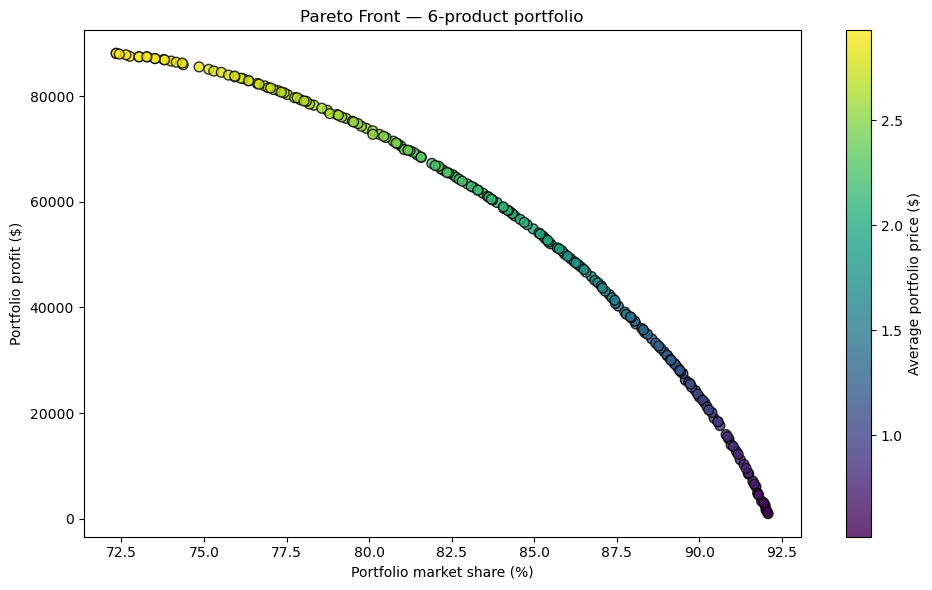

In [35]:
import matplotlib.pyplot as plt

avg_prices = np.array([
    np.mean([res.X[i, j * 2 + 1] for j in range(NUM_PRODUCTS)])
    for i in range(len(res.X))
])

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    portfolio_shares, portfolio_profits,
    c=avg_prices, cmap='viridis', s=50, alpha=0.8, edgecolors='black'
)
plt.colorbar(sc, ax=ax, label="Average portfolio price ($)")

ax.set_xlabel("Portfolio market share (%)")
ax.set_ylabel("Portfolio profit ($)")
ax.set_title(f"Pareto Front — {NUM_PRODUCTS}-product portfolio")

plt.tight_layout()
plt.show()